Feature Shape: (150, 4)
Label Shape: (150, 1)

===== Training with ReLU Activation =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ReLU Test Accuracy: 0.9333333373069763

===== Training with Sigmoid Activation =====
Sigmoid Test Accuracy: 0.9666666388511658

===== Activation Function Comparison =====
ReLU Accuracy   : 0.9333
Sigmoid Accuracy: 0.9667
Observation: Sigmoid performed similarly or better (rare case).


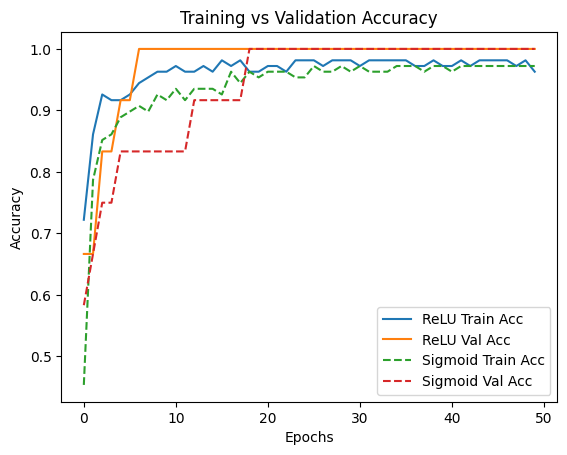

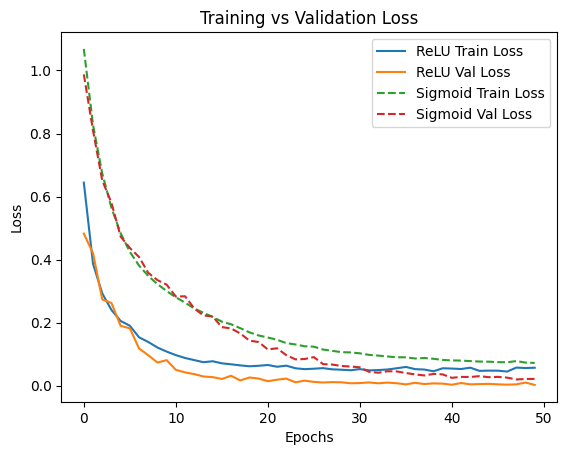

In [2]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# ============================================
# 2. LOAD DATASET
# ============================================
data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)


# ============================================
# 3. ONE-HOT ENCODING
# ============================================
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)


# ============================================
# 4. TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================
# 5. FEATURE SCALING
# ============================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================
# 6. FUNCTION TO BUILD MODEL
# ============================================
def build_model(activation_function):
    model = Sequential()

    # Hidden Layer
    model.add(Dense(16, activation=activation_function, input_shape=(4,)))

    # Output Layer (Softmax for classification)
    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ============================================
# 7. TRAIN MODEL WITH ReLU
# ============================================
print("\n===== Training with ReLU Activation =====")
model_relu = build_model('relu')

history_relu = model_relu.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    verbose=0
)

loss_relu, acc_relu = model_relu.evaluate(X_test, y_test, verbose=0)

print("ReLU Test Accuracy:", acc_relu)


# ============================================
# 8. TRAIN MODEL WITH Sigmoid
# ============================================
print("\n===== Training with Sigmoid Activation =====")
model_sigmoid = build_model('sigmoid')

history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    verbose=0
)

loss_sigmoid, acc_sigmoid = model_sigmoid.evaluate(X_test, y_test, verbose=0)

print("Sigmoid Test Accuracy:", acc_sigmoid)


# ============================================
# 9. COMPARISON OUTPUT
# ============================================
print("\n===== Activation Function Comparison =====")
print(f"ReLU Accuracy   : {acc_relu:.4f}")
print(f"Sigmoid Accuracy: {acc_sigmoid:.4f}")

if acc_relu > acc_sigmoid:
    print("Observation: ReLU performs better due to faster convergence and reduced vanishing gradient.")
else:
    print("Observation: Sigmoid performed similarly or better (rare case).")


# ============================================
# 10. PLOT TRAINING HISTORY
# ============================================
plt.figure()

# Accuracy plot
plt.plot(history_relu.history['accuracy'], label='ReLU Train Acc')
plt.plot(history_relu.history['val_accuracy'], label='ReLU Val Acc')

plt.plot(history_sigmoid.history['accuracy'], linestyle='--', label='Sigmoid Train Acc')
plt.plot(history_sigmoid.history['val_accuracy'], linestyle='--', label='Sigmoid Val Acc')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


# ============================================
# 11. LOSS PLOT
# ============================================
plt.figure()

plt.plot(history_relu.history['loss'], label='ReLU Train Loss')
plt.plot(history_relu.history['val_loss'], label='ReLU Val Loss')

plt.plot(history_sigmoid.history['loss'], linestyle='--', label='Sigmoid Train Loss')
plt.plot(history_sigmoid.history['val_loss'], linestyle='--', label='Sigmoid Val Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()